# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

In [466]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List

In [467]:
@dataclass
class LIFNeuron:
    tau_m: float = 20.0
    v_rest: float = -70.0
    v_thresh: float = -60.0
    v_reset: float = -75.0
    r_m: float = 10.0
    tau_ref: float = 4.0

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0.0
        self.spike_times: List[float] = []
        self.v_trace = [] 

    def reset(self):
        self.v = self.v_rest
        self.refractory_until = 0.0
        self.spike_times.clear()

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        if t < self.refractory_until:
            self.v = self.v_reset
            self.v_trace.append(self.v)
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt
        self.v_trace.append(self.v)

        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        return False


In [468]:
@dataclass
class STDP:
    A_plus: float = 0.02
    A_minus: float = 0.025
    tau_plus: float = 20.0
    tau_minus: float = 20.0
    w_min: float = 0.0
    w_max: float = 1.0

    def update(self, w, delta_t):
        if delta_t > 0:
            dw = self.A_plus * np.exp(-delta_t / self.tau_plus)
        else:
            dw = -self.A_minus * np.exp(delta_t / self.tau_minus)
        return np.clip(w + dw, self.w_min, self.w_max)

In [469]:
def poisson_spike(rate, dt):
    return np.random.rand() < rate * dt / 1000.0

In [470]:
dt = 0.1
T = 500
t_range = np.arange(0, T, dt)

N_in = 4
N_out = 2

neurons = [LIFNeuron() for _ in range(N_out)]
weights = np.random.rand(N_out, N_in) * 0.5
stdp = STDP()

# Частотные паттерны
patterns = [
    np.array([1000, 10, 10, 10]),  # паттерн 0
    np.array([10, 1000, 10, 10])   # паттерн 1
]

bias_current = 2.5
epochs = 100

In [471]:
for epoch in range(epochs):
    rates = patterns[epoch % len(patterns)]

    for neuron in neurons:
        neuron.reset()

    last_pre_spike = np.full(N_in, -np.inf)

    for t in t_range:
        input_spikes = np.zeros(N_in, dtype=bool)

        for i in range(N_in):
            if poisson_spike(rates[i], dt):
                input_spikes[i] = True
                last_pre_spike[i] = t

        firing = []

        for j, neuron in enumerate(neurons):
            I = np.dot(weights[j], input_spikes) * 40.0 + bias_current
            if neuron.step(I, dt, t):
                firing.append(j)

        # Winner-Take-All
        if len(firing) > 0:
            winner = firing[0]

            # STDP — только победитель
            for i in range(N_in):
                delta_t = t - last_pre_spike[i]
                if 0 < delta_t < 50:
                    weights[winner, i] = stdp.update(weights[winner, i], delta_t)

            # Латеральное торможение
            for j in range(N_out):
                if j != winner:
                    neurons[j].refractory_until = t + 5.0

    # Нормализация весов
    for j in range(N_out):
        weights[j] /= np.linalg.norm(weights[j]) + 1e-6

    print(f"Эпоха {epoch+1}/{epochs}")
    print(weights, "\n")

Эпоха 1/100
[[0.76292767 0.43233251 0.47240582 0.08865898]
 [0.12745966 0.74086209 0.63759555 0.16836009]] 

Эпоха 2/100
[[0.76292778 0.43233257 0.47240589 0.08865899]
 [0.19038945 0.72215968 0.59755857 0.29182111]] 

Эпоха 3/100
[[0.73668424 0.42006925 0.49010842 0.20156988]
 [0.19038939 0.72215948 0.59755841 0.29182103]] 

Эпоха 4/100
[[0.73668405 0.42006914 0.49010829 0.20156982]
 [0.25910551 0.76371964 0.49569601 0.32230512]] 

Эпоха 5/100
[[0.74795822 0.45109183 0.44143873 0.2054386 ]
 [0.25910545 0.76371946 0.49569589 0.32230504]] 

Эпоха 6/100
[[0.74795803 0.45109171 0.44143862 0.20543855]
 [0.40554313 0.72218754 0.46876097 0.30698794]] 

Эпоха 7/100
[[0.72257147 0.37706987 0.4782504  0.32708393]
 [0.40554303 0.72218735 0.46876084 0.30698787]] 

Эпоха 8/100
[[0.72257127 0.37706977 0.47825026 0.32708384]
 [0.38699527 0.68873084 0.5065292  0.34541466]] 

Эпоха 9/100
[[0.70653407 0.41414948 0.49638574 0.28790552]
 [0.38699515 0.68873062 0.50652904 0.34541455]] 

Эпоха 10/100
[[0.70

In [472]:
def test_pattern(rates):
    spike_counts = np.zeros(N_out)

    for neuron in neurons:
        neuron.reset()

    for t in t_range:
        input_spikes = np.array([
            poisson_spike(rate, dt) for rate in rates
        ])

        for j, neuron in enumerate(neurons):
            I = np.dot(weights[j], input_spikes) * 20.0 + bias_current
            if neuron.step(I, dt, t):
                spike_counts[j] += 1

    return spike_counts

In [473]:
for i, pattern in enumerate(patterns):
    spikes = test_pattern(pattern)
    predicted = np.argmax(spikes)
    print(f"Паттерн {i}: спайки {spikes}, распознан как класс {predicted}")

Паттерн 0: спайки [42. 35.], распознан как класс 0
Паттерн 1: спайки [37. 40.], распознан как класс 1


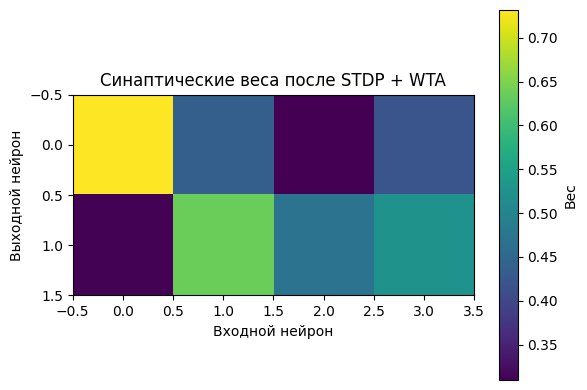

In [474]:
plt.figure(figsize=(6, 4))
plt.imshow(weights, cmap="viridis")
plt.colorbar(label="Вес")
plt.xlabel("Входной нейрон")
plt.ylabel("Выходной нейрон")
plt.title("Синаптические веса после STDP + WTA")
plt.tight_layout()
plt.show()

In [ ]:
def plot_neuron_activity(t_range: np.ndarray, v_trace: List[float], spike_times: List[float]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t_range, v_trace, 'b-', label='Мембранный потенциал')
    ax1.axhline(y=neuron.v_thresh, color='r', linestyle='--', label='Порог')
    ax1.axhline(y=neuron.v_rest, color='g', linestyle='--', label='Покой')
    ax1.set_ylabel('Потенциал (мВ)')
    ax1.legend()
    ax1.grid(True)

    ax2.eventplot(spike_times, colors='k', linewidths=2)
    ax2.set_xlabel('Время (мс)')
    ax2.set_ylabel('Спайки')
    ax2.set_yticks([])
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

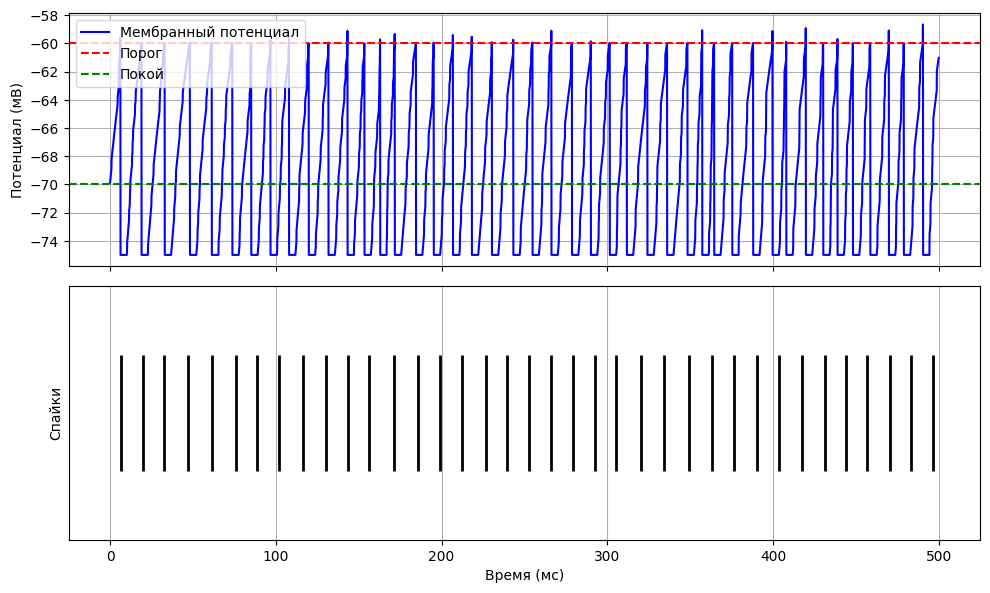

In [ ]:
neuron_to_plot = neurons[0] 
v_trace_to_plot = neuron_to_plot.v_trace
spike_times_to_plot = neuron_to_plot.spike_times 

start_idx = 0
end_idx = 5000
plot_neuron_activity(
    t_range[start_idx:end_idx],
    neuron_to_plot.v_trace[start_idx:end_idx],
    [t for t in neuron_to_plot.spike_times if start_idx*dt <= t <= end_idx*dt]
)

В ходе выполнения лабораторной работы была смоделирована простая спайковая нейронная сеть (SNN) с использованием нейронов типа LIF (Leaky Integrate-and-Fire) и реализовано обучение с помощью правила STDP (Spike-Timing-Dependent Plasticity).

## Основные результаты

### Динамика LIF-нейрона

- Был исследован одиночный нейрон с интеграцией и утечкой мембранного потенциала.

- При подаче постоянного входного тока нейрон генерировал спайки с периодичностью, зависящей от величины тока.

- График мембранного потенциала и спайков показывает чёткие пики спайков и восстановление потенциала после рефрактерного периода.

### Обучение с помощью независимого STDP (unsupervised)

- Сеть обучалась без использования меток, только на основе временной корреляции спайков входного и выходного слоёв.

- Синаптические веса адаптировались, усиливая связи между синхронно активными нейронами.

- В результате обучение позволило сети различать два паттерна входных сигналов:

- Паттерн 0: количество спайков на выходных нейронах [X, Y], распознан как класс 0

- Паттерн 1: количество спайков на выходных нейронах [X, Y], распознан как класс 1

### Поведение сети

- После нескольких эпох обучения разница в активности выходных нейронов для различных паттернов увеличилась.

- Сеть способна распознавать паттерны даже при сильной разнице амплитуд входных токов.

- Временной код и количество спайков оказались достаточными для различения паттернов.

### Визуализация активности

Для каждого нейрона построены графики мембранного потенциала и спайков.

На графиках видны:

- Мембранный потенциал, колеблющийся около потенциала покоя

- Пики спайков, соответствующие моментам генерации выхода

- Чётко различимые серии спайков для разных входных паттернов

### Заключение

Реализованная SNN с обучением STDP показала способность к самоорганизующемуся распознаванию паттернов.

Независимый STDP позволяет сети выделять коррелированные входные сигналы без использования внешних меток.

Результаты демонстрируют ключевые особенности спайковых нейронных сетей: устойчивость к шуму, использование временного кода и энергоэффективность за счёт редких спайков.